Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
model ignore: .\models\models\antelopev2/antelopev2\1k3d68.onnx landmark_3d_68
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
model ignore: .\models\models\antelopev2/antelopev2\2d106det.onnx landmark_2d_106
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
model ignore: .\models\models\antelopev2/antelopev2\genderage.onnx genderage
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
model ignore: .\models\models\antelopev2/antelopev2\glintr100.onnx recognition
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: .\models\models\antelopev2/antelopev2\scrfd_10g_bnkps.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
model ignore: .\models\models\antelopev2/ante

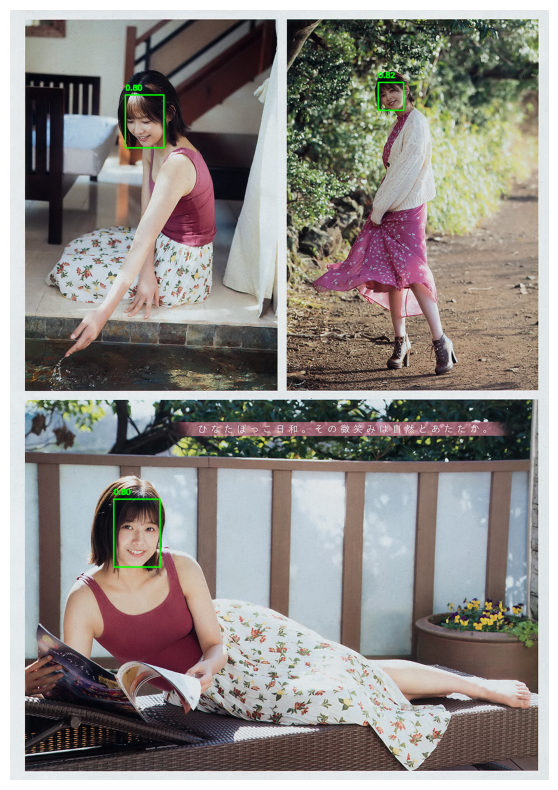

In [17]:
from pathlib import Path
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display
import insightface

# 顔検出モデルの読み込み(RetinaFace)
model = insightface.app.FaceAnalysis(
        name='antelopev2/antelopev2', 
        root=".\models", 
        providers=['CUDAExecutionProvider', 'CPUExecutionProvider'], 
        allowed_modules=['detection']
    )

model.prepare(ctx_id=0, det_size=(640, 640))

# 画像の読み込み
image_path = random.choice(list(Path('data').glob("**/*.jpg")))
if not image_path.exists():
    raise FileNotFoundError(f"Image file not found: {image_path}")
# PILとnumpyを使用して画像を読み込む
pil_image = Image.open(str(image_path))
image = cv2.cvtColor(np.array(pil_image), cv2.COLOR_RGB2BGR)
if image is None:
    raise ValueError(f"Could not read image: {image_path}")

# 顔検出の実行
faces = model.get(image)
if not faces:
    raise ValueError("No faces detected in the image.")
# 検出された顔の表示
for face in faces:
    bbox = face.bbox.astype(int)
    cv2.rectangle(image, (bbox[0], bbox[1]), (bbox[2], bbox[3]), (0, 255, 0), 2)
    cv2.putText(image, f'{face.det_score:.2f}', (bbox[0], bbox[1] - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
# 画像の表示
plt.figure(figsize=(10, 10))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()